# LAB 04

In [29]:
from sklearn.datasets import load_wine
dataset = load_wine ()
X = dataset["data"]
y = dataset["target"]
feature_names = dataset["feature_names"]

feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import numpy as np
import matplotlib.pyplot as plt

print("Record available:", X.shape[0])
print("Missing values:", np.count_nonzero(X)-(X.shape[0]*X.shape[1]))
print("Elements for each class:", np.unique(X.shape[1]))

Record available: 178
Missing values: 0
Elements for each class: [13]


1.0

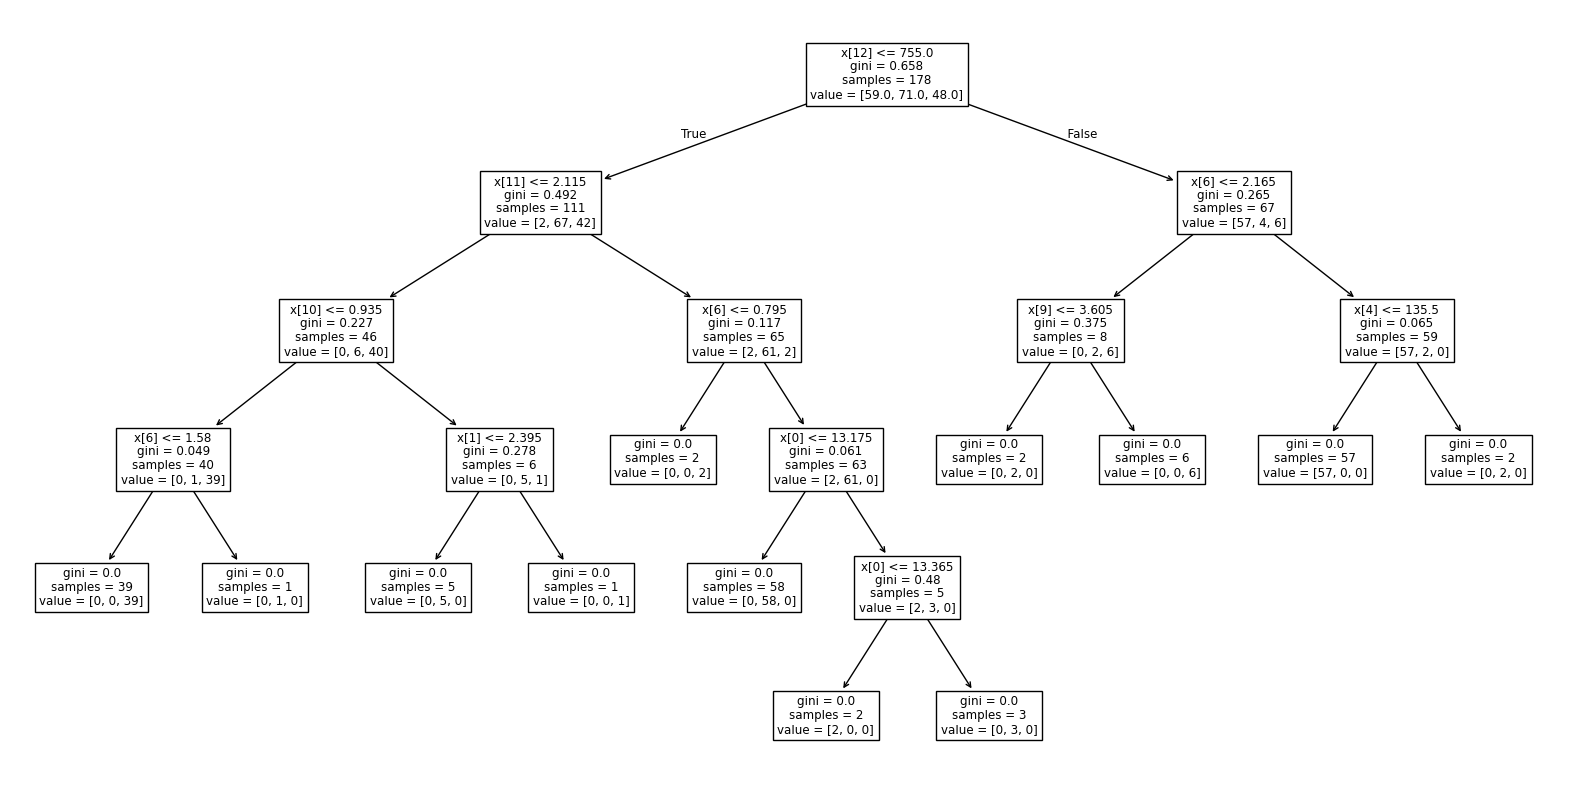

In [ ]:

tree = DecisionTreeClassifier()
tree.fit(X,y)
plt.figure(figsize=(20, 10))  # puoi aumentare ancora i valori se vuoi
plot_tree(tree)

In [32]:
from sklearn.metrics import accuracy_score
y_predicted = tree.predict(X)

score = accuracy_score(y, y_predicted)
score

1.0

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [36]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_predicted = tree.predict(X_test)
score = accuracy_score(y_test, y_predicted)
score


0.9444444444444444

In [38]:
from sklearn.model_selection import ParameterGrid
params = {
    "max_depth": [None , 2, 4, 8],
    "splitter": ["best", "random"]
}
for config in ParameterGrid(params):
    print(config)
    clf = DecisionTreeClassifier (** config)
    clf.fit(X_train, y_train)
    y_predicted = clf.predict(X_test)
    score = accuracy_score(y_test, y_predicted)
    print("Score obtained: ", score)
    print("--------------------------------")


{'max_depth': None, 'splitter': 'best'}
Score obtained:  0.9444444444444444
--------------------------------
{'max_depth': None, 'splitter': 'random'}
Score obtained:  0.9444444444444444
--------------------------------
{'max_depth': 2, 'splitter': 'best'}
Score obtained:  0.8611111111111112
--------------------------------
{'max_depth': 2, 'splitter': 'random'}
Score obtained:  0.8333333333333334
--------------------------------
{'max_depth': 4, 'splitter': 'best'}
Score obtained:  0.9444444444444444
--------------------------------
{'max_depth': 4, 'splitter': 'random'}
Score obtained:  0.8055555555555556
--------------------------------
{'max_depth': 8, 'splitter': 'best'}
Score obtained:  0.9444444444444444
--------------------------------
{'max_depth': 8, 'splitter': 'random'}
Score obtained:  0.9444444444444444
--------------------------------


In [50]:
from sklearn.model_selection import KFold
# Split the datasets into two:
# - X_train_valid: the dataset used for the k-fold cross -validation
# - X_test: the dataset used for the final testing (this will NOT
# be seen by the classifier during the training/validation phases)
X_train_valid , X_test , y_train_valid , y_test = train_test_split (X, y, test_size=0.20, random_state=42)
kf = KFold (5) # 5-fold cross -validation
# X and y are the arrays to be split

best_configuration_saved = None
best_score = 0
best_config = None

for train_indices , validation_indices in kf.split(X_train_valid):
    X_train = X_train_valid[train_indices]
    X_valid = X_train_valid[validation_indices]
    y_train = y_train_valid[train_indices]
    y_valid = y_train_valid[validation_indices]
    for config in ParameterGrid(params):
        clf = DecisionTreeClassifier (** config)
        clf.fit(X_train, y_train)
        y_predicted = clf.predict(X_valid)
        score = accuracy_score(y_valid, y_predicted)
        if score > best_score:
            best_score = score    
            best_configuration_saved = (X_train, X_valid, y_train, y_valid)
            best_config = config

print("Best score:", best_score)
print("best_config", best_config)

Best score: 0.9655172413793104
best_config {'max_depth': 4, 'splitter': 'random'}
